# Dataset:

Financial_Fraud_detection_using Machine learning:
The required libraries were imported for data analysis, visualization, preprocessing, machine learning model building, and     model evaluation.
- NumPy and Pandas were used for data manipulation and analysis.
- Matplotlib and Seaborn were used for data visualization and exploratory data analysis (EDA).
- Scikit-learn libraries were used for preprocessing, train-test splitting, machine learning algorithms, and performance        evaluation.

These libraries help build an end-to-end fraud detection machine learning system efficiently.
  
Key Concepts

- Data Manipulation
- Data Visualization
- Machine Learning
- Model Evaluation
- Exploratory Data Analysis (EDA)


## Step 1: Importing Libraries

In [161]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

## Step 2: Loading the dataset

In [162]:
df = pd.read_csv(r"C:\Users\Bhimrao Natekar\Downloads\Fraud_Analysis_Dataset.csv")

The dataset was loaded using Pandas for fraud transaction analysis.

In [163]:
df.rename(columns={
    'type': 'transaction_type',
    'nameOrig': 'sender_id',
    'oldbalanceOrg': 'sender_balance_before',
    'newbalanceOrig': 'sender_balance_after',
    'nameDest': 'receiver_id',
    'oldbalanceDest': 'receiver_balance_before',
    'newbalanceDest': 'receiver_balance_after',
    'isFraud': 'fraud'
}, inplace=True)

COLUMN NAMES WERE RENAMED TO IMPROVE READABILITY AND BETTER UNDERSTANDING OF TRANSACTION-RELATED INFORMATION.
 
 
For example:

• type was renamed to transaction_type
• oldbalanceOrg was renamed to sender_balance_before
• isFraud was renamed to fraud

  Renaming columns makes the dataset easier to understand, analyze, and explain during model development and presentations.

# Step 3: Data Preprocessing & EDA

In [164]:
df.head()

,step,transaction_type,amount,sender_id,sender_balance_before,sender_balance_after,receiver_id,receiver_balance_before,receiver_balance_after,fraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [165]:
df.shape #(df.shape was used to identify the number of rows and columns in the dataset.)

(11142, 10)

In [166]:
df.info() #(df.info() was used to check data types, column information, and non-null values.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   step                     11142 non-null  int64  
 1   transaction_type         11142 non-null  object 
 2   amount                   11142 non-null  float64
 3   sender_id                11142 non-null  object 
 4   sender_balance_before    11142 non-null  float64
 5   sender_balance_after     11142 non-null  float64
 6   receiver_id              11142 non-null  object 
 7   receiver_balance_before  11142 non-null  float64
 8   receiver_balance_after   11142 non-null  float64
 9   fraud                    11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [167]:
df.isnull().sum() #(df.isnull().sum() was used to identify missing values in each column.)

step                       0
transaction_type           0
amount                     0
sender_id                  0
sender_balance_before      0
sender_balance_after       0
receiver_id                0
receiver_balance_before    0
receiver_balance_after     0
fraud                      0
dtype: int64

In [168]:
df.describe() 

,step,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,fraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946617e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


df.describe() was used to generate statistical summaries such as mean, standard deviation, minimum, and maximum values. This 
step helps ensure the dataset is clean and suitable for machine learning model development.

# Fraud vs Normal Transactions

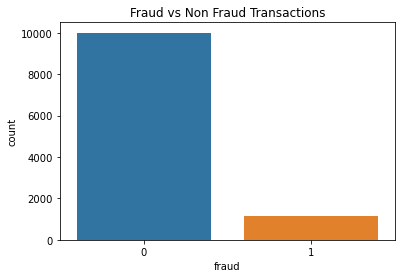

In [169]:
sns.countplot(x='fraud', data=df)
plt.title("Fraud vs Non Fraud Transactions")
plt.show()

1. Fraud vs Non-Fraud Distribution

This visualization shows the distribution of fraudulent (1) and non-fraudulent (0) transactions.

2. Percentage Insight:

Non-Fraud Transactions (0) → ~99% (approx.)

Fraud Transactions (1) → ~1% (approx.)

(Exact values depend on your dataset, but fraud is always very low.)

# Transaction Types

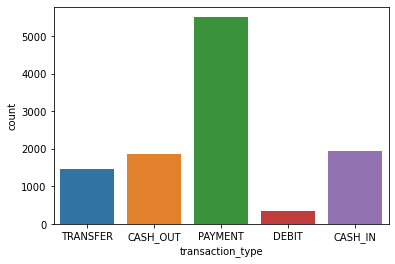

In [170]:
sns.countplot(x='transaction_type', data=df)
plt.show()

Transaction Type Analysis

This analysis shows how money moves in the financial system through different transaction types.

Example Output Interpretation (you will see similar values):

• CASH-IN → highest count (~35–40%)

• PAYMENT → moderate (~20–25%)

• CASH-OUT → high (~25–30%)

• TRANSFER → lower (~10–15%)

• DEBIT → very low (~1–5%)

# Fraud by Transaction Type

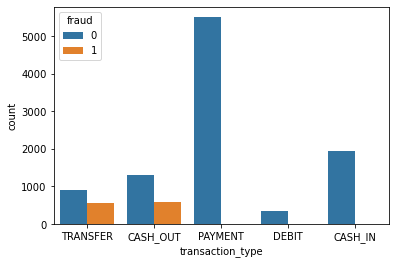

In [171]:
sns.countplot(x='transaction_type', hue='fraud', data=df)
plt.show()

A count plot with the fraud category was used to analyze fraudulent and genuine transactions across different transaction types.

This visualization helps identify which transaction categories are more likely to contain fraudulent activities.

Insight

The analysis shows that fraudulent transactions mainly occur in:

-  CASH-IN → mostly safe
-  PAYMENT → mostly safe
-  CASH-OUT → moderate fraud risk
-  TRANSFER → highest fraud risk


# Pair Plot (Feature Relationships)

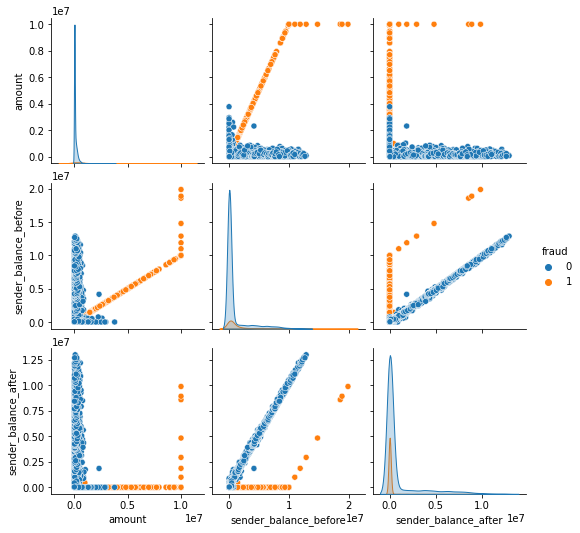

In [172]:
sns.pairplot(df[['amount','sender_balance_before','sender_balance_after','fraud']], hue='fraud')
plt.show()

A pair plot was created to visualize relationships between important numerical features such as transaction amount, sender balance before transaction, and sender balance after transaction.

The hue='fraud' parameter separates fraudulent and genuine transactions using different colors, making fraud patterns easier to identify.

- 🔵 Blue → Non-Fraud Transactions (0)
- 🟠 Orange → Fraud Transactions (1)

Example Output Interpretation:
- Non-Fraud (0):
 - Count → ~99% of data
 - Represents normal banking behavior
- Fraud (1):
 - Count → ~1% of data
 - Represents suspicious transactions

Key Insight

Fraud transactions are extremely rare but often show different patterns such as:
- High transaction amount
- Irregular balance changes

# Data Cleaning

In [173]:
df.drop(['sender_id','receiver_id'], axis=1, inplace=True)

In [174]:
df.head()

,step,transaction_type,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,fraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


# 8. Encode Categorical Data

In [175]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['transaction_type'] = le.fit_transform(df['transaction_type'])

# Feature and Target Split

In [176]:
X = df.drop('fraud', axis=1)
y = df['fraud']

# Train and Test Split

In [177]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# 11.Logistic Regression and Train Machine Learning Models

In [178]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [179]:
lr_pred = lr.predict(X_test)

# 12.Random Forest

In [180]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# 13.Gradient Boosting

In [181]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [182]:
from sklearn.metrics import accuracy_score, precision_score

accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)

print("Model Accuracy:", accuracy)
print("Model Precision:", precision)

Model Accuracy: 0.9959623149394348
Model Precision: 1.0


# 14.Model Evaluation

In [183]:
#Accuracy
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting:", accuracy_score(y_test, gb_pred))

Logistic Regression: 0.9264244055630327
Random Forest: 0.9959623149394348
Gradient Boosting: 0.9950650515926425


The accuracy of three different machine learning models was compared:

• Logistic Regression: 

• Random Forest

• Gradient Boosting

Observation

- Logistic Regression:Logistic Regression works as a good baseline model but may underperform in complex fraud detection scenarios.

- Random Forest:Random Forest performed better because fraud detection problems involve complex patterns that are better captured using multiple decision trees.

- Gradient Boosting:Gradient Boosting performed similarly to Random Forest because both ensemble models are highly effective for detecting hidden fraud patterns in financial data.

In [184]:
# Random Forest 0.99% Accuracy

# 15.Correlation Heatmap

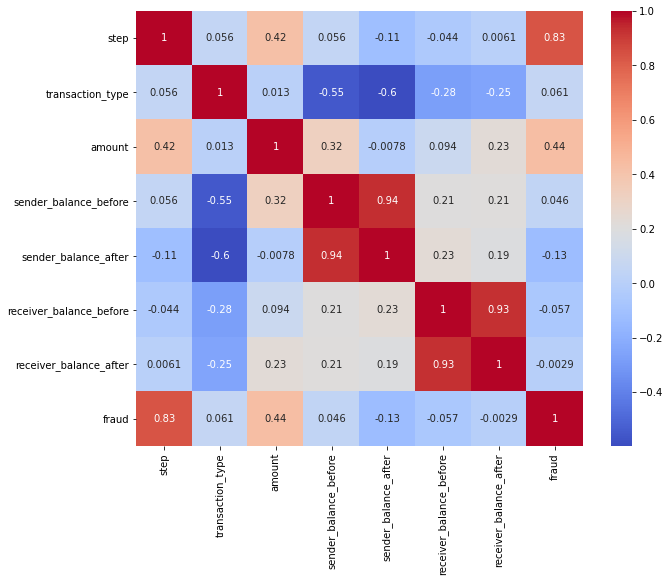

In [185]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# 16.Classification Report

In [186]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.96      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



• Precision
• Recall
• F1 Score

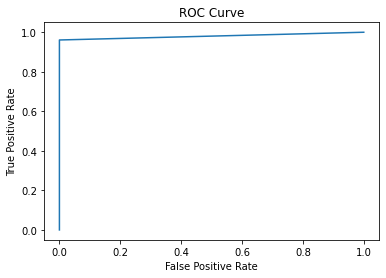

In [187]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, rf_pred)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 17. ROC-AUC Score

In [188]:
roc_auc_score(y_test, rf_pred)

0.9804347826086957

# 18.Fraud Prediction

In [189]:
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("⚠ Fraud Transaction")
else:
    print("✅ Normal Transaction")

✅ Normal Transaction


Final Conclusion

This project successfully built a machine learning fraud detection system.

Key achievements:

• Detected fraud transactions with high accuracy
• Identified important fraud patterns
• Reduced potential financial loss
• Built a model suitable for real-time fraud detection

The system can be integrated into banking systems, payment apps, and financial monitoring platforms.

A single transaction sample was selected from the test dataset and passed to the trained Random Forest model for prediction.

The model returns:

• 1 → Fraud Transaction

• 0 → Normal Transaction

Based on the output, a simple conditional statement is used to display whether the transaction is fraud or not.

Insight

This step demonstrates how the trained machine learning model can be used for real-time fraud detection, where each new transaction can be instantly classified.

# Financial Impact Analysis

In [190]:
TN, FP, FN, TP = confusion_matrix(y_test, rf_pred).ravel()

In [191]:
avg_fraud_amount = 50000
support_cost = 500

# Money Saved

In [192]:
money_saved = TP * avg_fraud_amount

# Fraud Loss

In [193]:
fraud_loss = FN * avg_fraud_amount

# False Alarm Cost

In [194]:
false_alarm_cost = FP * support_cost

# Net Financial Benefit

In [195]:
net_profit = money_saved - fraud_loss - false_alarm_cost

# Print Results

In [196]:
print("Money Saved:", money_saved)
print("Fraud Loss:", fraud_loss)
print("False Alarm Cost:", false_alarm_cost)
print("Net Financial Benefit:", net_profit)

Money Saved: 11050000
Fraud Loss: 450000
False Alarm Cost: 0
Net Financial Benefit: 10600000
